In [51]:
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense

In [52]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [53]:
base_path = r"C:\Users\Fahad\Desktop\my works\socially relevant Project\tinyML-HAR\data\UCI HAR Dataset"
train_path = os.path.join(base_path, "train", "Inertial Signals")


In [54]:
train_path = os.path.join(base_path, "train", "Inertial Signals")
test_path  = os.path.join(base_path, "test", "Inertial Signals")

In [55]:
acc_x = np.loadtxt(os.path.join(train_path, "total_acc_x_train.txt"))
acc_y = np.loadtxt(os.path.join(train_path, "total_acc_y_train.txt"))
acc_z = np.loadtxt(os.path.join(train_path, "total_acc_z_train.txt"))

In [56]:
gyro_x = np.loadtxt(os.path.join(train_path, "body_gyro_x_train.txt"))
gyro_y = np.loadtxt(os.path.join(train_path, "body_gyro_y_train.txt"))
gyro_z = np.loadtxt(os.path.join(train_path, "body_gyro_z_train.txt"))

In [57]:
X_train = np.stack([acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z], axis=-1)

In [58]:
y_train = np.loadtxt(os.path.join(base_path, "train", "y_train.txt")).astype(int)

In [59]:
print("X_train shape:", X_train.shape)
print("y_train shape:",y_train.shape)

X_train shape: (7352, 128, 6)
y_train shape: (7352,)


In [60]:
print(X_train[0].shape)

(128, 6)


In [61]:
window = X_train[0] 
df = pd.DataFrame(
    window,
    columns=["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
)

df["label"] = y_train[0] 

df.to_csv("window_0.csv", index=False)

In [62]:
df.head()

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,label
0,1.012817,-0.123217,0.102934,0.030191,0.066014,0.022859,5
1,1.022833,-0.126876,0.105687,0.043711,0.042699,0.010316,5
2,1.022028,-0.124004,0.102102,0.035688,0.074850,0.013250,5
3,1.017877,-0.124928,0.106553,0.040402,0.057320,0.017751,5
4,1.023680,-0.125767,0.102814,0.047097,0.052343,0.002553,5


In [63]:
acc_x_test = np.loadtxt(os.path.join(test_path, "total_acc_x_test.txt"))
acc_y_test = np.loadtxt(os.path.join(test_path, "total_acc_y_test.txt"))
acc_z_test = np.loadtxt(os.path.join(test_path, "total_acc_z_test.txt"))

In [64]:
gyro_x_test = np.loadtxt(os.path.join(test_path, "body_gyro_x_test.txt"))
gyro_y_test = np.loadtxt(os.path.join(test_path, "body_gyro_y_test.txt"))
gyro_z_test = np.loadtxt(os.path.join(test_path, "body_gyro_z_test.txt"))

In [65]:
X_test = np.stack([acc_x_test, acc_y_test, acc_z_test, gyro_x_test, gyro_y_test, gyro_z_test], axis=-1)

In [66]:
y_test = np.loadtxt(os.path.join(base_path, "test", "y_test.txt")).astype(int)

In [67]:
# ─── LABEL MAPPING FUNCTION ───────────────────────────────────────────────────
def map_label(l):
    if l in [1, 2, 3]: return 0   # Walking (all variants)
    if l == 4:          return 1   # Sitting
    if l == 5:          return 2   # Standing
    if l == 6:          return 3   # Lying

# ─── MAP LABELS SEPARATELY — NEVER MIX TRAIN AND TEST ─────────────────────────
y_train_mapped = np.array([map_label(i) for i in y_train])
y_test_mapped  = np.array([map_label(i) for i in y_test])

print("X_train shape:", X_train.shape)   # (7352, 128, 6)
print("X_test shape: ", X_test.shape)    # (2947, 128, 6)
print("Train class distribution:", dict(zip(*np.unique(y_train_mapped, return_counts=True))))
print("Test  class distribution:", dict(zip(*np.unique(y_test_mapped,  return_counts=True))))

X_train shape: (7352, 128, 6)
X_test shape:  (2947, 128, 6)
Train class distribution: {np.int64(0): np.int64(3285), np.int64(1): np.int64(1286), np.int64(2): np.int64(1374), np.int64(3): np.int64(1407)}
Test  class distribution: {np.int64(0): np.int64(1387), np.int64(1): np.int64(491), np.int64(2): np.int64(532), np.int64(3): np.int64(537)}


In [68]:
print("X_test shape:", X_test.shape)
print("y_test shape:",y_test.shape)

X_test shape: (2947, 128, 6)
y_test shape: (2947,)


In [69]:
# ─── TRANSITION DETECTION FUNCTION ────────────────────────────────────────────
# Works on ONE split at a time so no ghost transitions bleed across boundaries
def detect_transitions(y_mapped):
    """
    Marks a window as Transition (4) if its label differs from
    the window immediately before OR after it.
    Only operates within a single contiguous recording split.
    Returns a copy — never mutates the input.
    """
    y_final = y_mapped.copy()
    transition_indices = []

    for i in range(1, len(y_mapped) - 1):
        if y_mapped[i] != y_mapped[i - 1] or y_mapped[i] != y_mapped[i + 1]:
            transition_indices.append(i)
            y_final[i] = 4  # Transition class

    return y_final, transition_indices


# ─── APPLY SEPARATELY TO TRAIN AND TEST ───────────────────────────────────────
y_train_final, train_transition_idx = detect_transitions(y_train_mapped)
y_test_final,  test_transition_idx  = detect_transitions(y_test_mapped)

print("Train transitions detected:", len(train_transition_idx))
print("Test  transitions detected:", len(test_transition_idx))
print("Train class distribution after transitions:",
      dict(zip(*np.unique(y_train_final, return_counts=True))))
print("Test  class distribution after transitions:",
      dict(zip(*np.unique(y_test_final,  return_counts=True))))

Train transitions detected: 338
Test  transitions detected: 142
Train class distribution after transitions: {np.int64(0): np.int64(3202), np.int64(1): np.int64(1200), np.int64(2): np.int64(1291), np.int64(3): np.int64(1321), np.int64(4): np.int64(338)}
Test  class distribution after transitions: {np.int64(0): np.int64(1352), np.int64(1): np.int64(455), np.int64(2): np.int64(497), np.int64(3): np.int64(501), np.int64(4): np.int64(142)}


In [70]:
# ─── NOT-ON-BODY GENERATOR — fixed units + 5 realistic scenarios ──────────────
def generate_not_on_body(num_windows=1500, seed=42):
    """
    Generates 5 types of realistic 'phone not on body' scenarios.
    Each type has distinct sensor characteristics to teach the model
    variety — fixes the previous unit bug (was 9.8 m/s², now 1.0g)
    and prevents the model from just learning one easy pattern.

    Scenarios:
        Type 0 — Flat on table        : gravity along one axis, near-zero gyro
        Type 1 — Tilted on surface    : gravity split across axes, near-zero gyro
        Type 2 — Random orientation   : gravity in any direction, near-zero gyro
        Type 3 — Slight vibration     : gravity + small periodic acc (table fan etc)
        Type 4 — Charging, moving cable: gravity + tiny random acc bursts
    """
    np.random.seed(seed)
    windows = []
    per_type = num_windows // 5   # equal split across 5 types

    for scenario in range(5):
        for _ in range(per_type):

            if scenario == 0:
                # Flat on table — gravity mostly on one axis (Z dominant)
                g    = np.array([0.0, 0.0, 1.0])
                g   += np.random.normal(0, 0.02, 3)   # tiny placement error
                acc  = np.tile(g, (128, 1)) + np.random.normal(0, 0.01, (128, 3))
                gyro = np.random.normal(0, 0.005, (128, 3))

            elif scenario == 1:
                # Tilted on surface — gravity split between two axes
                angle = np.random.uniform(15, 75)     # tilt angle in degrees
                rad   = np.deg2rad(angle)
                g     = np.array([np.sin(rad), 0.0, np.cos(rad)])
                acc   = np.tile(g, (128, 1)) + np.random.normal(0, 0.015, (128, 3))
                gyro  = np.random.normal(0, 0.005, (128, 3))

            elif scenario == 2:
                # Random orientation — gravity in any direction, magnitude = 1g
                g    = np.random.uniform(-1, 1, size=3)
                g    = g / np.linalg.norm(g) * 1.0    # ← 1.0g NOT 9.8 m/s²
                acc  = np.tile(g, (128, 1)) + np.random.normal(0, 0.02, (128, 3))
                gyro = np.random.normal(0, 0.008, (128, 3))

            elif scenario == 3:
                # Slight vibration (table fan / washing machine nearby)
                g    = np.random.uniform(-1, 1, size=3)
                g    = g / np.linalg.norm(g) * 1.0
                t    = np.linspace(0, 2.56, 128)
                freq = np.random.uniform(5, 20)        # vibration frequency Hz
                vib  = 0.03 * np.sin(2 * np.pi * freq * t)
                acc  = np.tile(g, (128, 1)) + np.random.normal(0, 0.01, (128, 3))
                acc[:, 0] += vib                       # vibration on one axis
                gyro = np.random.normal(0, 0.01, (128, 3))

            elif scenario == 4:
                # Tiny random acc bursts (cable nudge / notification buzz)
                g    = np.random.uniform(-1, 1, size=3)
                g    = g / np.linalg.norm(g) * 1.0
                acc  = np.tile(g, (128, 1)) + np.random.normal(0, 0.01, (128, 3))
                # Random burst at a random timestep
                burst_start = np.random.randint(20, 100)
                burst_len   = np.random.randint(3, 10)
                acc[burst_start:burst_start+burst_len] += np.random.normal(0, 0.08, (burst_len, 3))
                gyro = np.random.normal(0, 0.008, (128, 3))

            window = np.concatenate([acc, gyro], axis=1)  # (128, 6)
            windows.append(window)

    return np.array(windows)   # (num_windows, 128, 6)

In [71]:
# ─── GENERATE NOB + APPEND TO CORRECT SPLITS ─────────────────────────────────
np.random.seed(42)

# Generate 1500 windows (300 per scenario type — much more variety than before)
not_on_body = generate_not_on_body(num_windows=1500, seed=42)
print(f"Generated NOB windows : {not_on_body.shape}")

# 80/20 split — keep train and test clean
nob_split         = int(0.8 * len(not_on_body))   # 1200 train, 300 test
not_on_body_train = not_on_body[:nob_split]        # (1200, 128, 6)
not_on_body_test  = not_on_body[nob_split:]        # (300,  128, 6)

# Append to CORRECT split only — never cross-contaminate
X_train       = np.concatenate([X_train,      not_on_body_train], axis=0)
y_train_final = np.concatenate([y_train_final, np.full(nob_split, 5, dtype=np.int64)], axis=0)

X_test        = np.concatenate([X_test,       not_on_body_test],  axis=0)
y_test_final  = np.concatenate([y_test_final,  np.full(300, 5, dtype=np.int64)],        axis=0)

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print("\nFinal train distribution:")
for cls, cnt in zip(*np.unique(y_train_final, return_counts=True)):
    print(f"  Class {cls} : {cnt}")
print("\nFinal test distribution:")
for cls, cnt in zip(*np.unique(y_test_final, return_counts=True)):
    print(f"  Class {cls} : {cnt}")

Generated NOB windows : (1500, 128, 6)
X_train shape : (8552, 128, 6)
X_test  shape : (3247, 128, 6)

Final train distribution:
  Class 0 : 3202
  Class 1 : 1200
  Class 2 : 1291
  Class 3 : 1321
  Class 4 : 338
  Class 5 : 1200

Final test distribution:
  Class 0 : 1352
  Class 1 : 455
  Class 2 : 497
  Class 3 : 501
  Class 4 : 142
  Class 5 : 300


In [72]:
# ─── MAGNITUDE CHANNEL FUNCTION ───────────────────────────────────────────────
def add_magnitude_channels(X):
    """
    Adds acc_magnitude and gyro_magnitude as channels 7 and 8.
    These are rotation-invariant features — key for orientation independence.
    Input : (N, 128, 6)
    Output: (N, 128, 8)
    """
    ax, ay, az = X[:, :, 0], X[:, :, 1], X[:, :, 2]
    gx, gy, gz = X[:, :, 3], X[:, :, 4], X[:, :, 5]

    acc_mag  = np.sqrt(ax**2 + ay**2 + az**2)   # (N, 128)
    gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)   # (N, 128)

    return np.concatenate(
        [X, acc_mag[..., np.newaxis], gyro_mag[..., np.newaxis]],
        axis=2
    )   # (N, 128, 8)

In [73]:
# Add magnitude channels to BOTH splits separately
X_train_mag = add_magnitude_channels(X_train)   # (7352+800, 128, 8)
X_test_mag  = add_magnitude_channels(X_test)    # (2947+200, 128, 8)

print("X_train_mag shape:", X_train_mag.shape)
print("X_test_mag  shape:", X_test_mag.shape)

X_train_mag shape: (8552, 128, 8)
X_test_mag  shape: (3247, 128, 8)


In [74]:
# Keep raw 6-channel version of train for rotation augmentation
X_train_raw8 = X_train_mag            # 8-channel version with mags
X_test_raw8  = X_test_mag             # test set — no augmentation ever

In [75]:
def random_rotation_matrix():
    # Generate random angles
    theta_x = np.random.uniform(0, 2*np.pi)
    theta_y = np.random.uniform(0, 2*np.pi)
    theta_z = np.random.uniform(0, 2*np.pi)

    # Rotation matrix for X-axis
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(theta_x), -np.sin(theta_x)],
        [0, np.sin(theta_x),  np.cos(theta_x)]
    ])

    # Rotation matrix for Y-axis
    Ry = np.array([
        [np.cos(theta_y), 0, np.sin(theta_y)],
        [0, 1, 0],
        [-np.sin(theta_y), 0, np.cos(theta_y)]
    ])

    # Rotation matrix for Z-axis
    Rz = np.array([
        [np.cos(theta_z), -np.sin(theta_z), 0],
        [np.sin(theta_z),  np.cos(theta_z), 0],
        [0, 0, 1]
    ])

    # Combined rotation matrix
    R = Rz @ Ry @ Rx
    return R


In [76]:
def rotate_window8_preserve_mags(window8, R):
    """
    Rotates only the raw 6 sensor channels (acc + gyro).
    Magnitude channels (cols 6 and 7) are copied directly from the
    original window — rotation never changes vector magnitude so
    recomputing is mathematically identical but wastes CPU cycles.

    Math: for any rotation matrix R,  ‖Rv‖ = ‖v‖
    because R is orthogonal: R.T @ R = I, so
    ‖Rv‖² = (Rv)ᵀ(Rv) = vᵀRᵀRv = vᵀv = ‖v‖²

    Args:
        window8 : np.ndarray of shape (128, 8)
                  cols 0-2 = acc xyz, 3-5 = gyro xyz,
                  col 6 = acc_mag,   col 7 = gyro_mag
        R       : (3,3) rotation matrix
    Returns:
        np.ndarray of shape (128, 8) with rotated axes + original mags
    """
    acc  = window8[:, :3]                          # (128, 3)
    gyro = window8[:, 3:6]                         # (128, 3)
    acc_mag_original  = window8[:, 6:7]            # (128, 1) — copy as-is
    gyro_mag_original = window8[:, 7:8]            # (128, 1) — copy as-is

    acc_rot  = acc  @ R.T                          # rotate accelerometer
    gyro_rot = gyro @ R.T                          # rotate gyroscope

    return np.concatenate(
        [acc_rot, gyro_rot, acc_mag_original, gyro_mag_original],
        axis=1
    )   # (128, 8)

In [77]:
def augment_train_rotations(X8, y, num_aug=1, seed=None):
    """
    Creates `num_aug` randomly rotated copies of every training window.
    Accepts 8-channel input (with pre-computed magnitudes) and
    passes them through rotate_window8_preserve_mags so magnitudes
    are never redundantly recomputed.

    Args:
        X8      : np.ndarray (N, 128, 8) — training set with mag channels
        y       : np.ndarray (N,)        — labels
        num_aug : int — how many rotated copies per window
        seed    : int — for reproducibility
    Returns:
        X_aug : np.ndarray (N * num_aug, 128, 8)
        y_aug : np.ndarray (N * num_aug,)
    """
    if seed is not None:
        np.random.seed(seed)

    X_aug = []
    y_aug = []

    for i in range(len(X8)):
        window8 = X8[i]                            # (128, 8)
        for _ in range(num_aug):
            R = random_rotation_matrix()
            rotated8 = rotate_window8_preserve_mags(window8, R)  # pass 8-ch window
            X_aug.append(rotated8)
            y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

In [78]:
num_aug = 1
X_rot, y_rot = augment_train_rotations(X_train_raw8, y_train_final, num_aug=num_aug, seed=42)

In [79]:
# ─── STEP 1: COMBINE + NORMALIZE ──────────────────────────────────────────────
X_train_combined = np.concatenate([X_train_raw8, X_rot], axis=0)
y_train_combined = np.concatenate([y_train_final, y_rot], axis=0)

mean = X_train_combined.mean(axis=(0, 1))   # (8,) — per channel
std  = X_train_combined.std(axis=(0, 1))    # (8,) — per channel

def normalize(X, mean, std):
    return (X - mean.reshape(1, 1, -1)) / std.reshape(1, 1, -1)

X_train_norm = normalize(X_train_combined, mean, std)
X_test_norm  = normalize(X_test_raw8,      mean, std)

print("After rotation augmentation + normalization:")
print(f"  X_train_norm : {X_train_norm.shape}")
print(f"  X_test_norm  : {X_test_norm.shape}")

'''
# ─── STEP 2: SYNTHETIC TRANSITION GENERATOR ───────────────────────────────────
def generate_synthetic_transitions(X_normalized, y_labels,
                                   n_synthetic=1000, seed=42):
    """
    Creates realistic transition windows by linearly blending two windows
    from DIFFERENT activity classes (0-3 only).

    Physical intuition:
        A real transition window contains the END of one activity
        and the START of another. A linear blend captures this
        mixed-signal naturally across 3 zones:

        Zone 1 [0%  - 35%] : pure class A  (activity before)
        Zone 2 [35% - 65%] : linear fade A → B  (the moment of change)
        Zone 3 [65% - 100%]: pure class B  (activity after)

    Only uses already-normalized data so blended windows stay
    in the same feature space as real training windows.
    """
    np.random.seed(seed)

    real_classes  = [0, 1, 2, 3]   # Walking, Sitting, Standing, Lying
    class_indices = {
        c: np.where(y_labels == c)[0]
        for c in real_classes
    }

    print("Source windows per class for blending:")
    cnames = ['Walking', 'Sitting', 'Standing', 'Lying']
    for c in real_classes:
        print(f"  Class {c} ({cnames[c]:<10}): {len(class_indices[c])} windows")

    X_trans = []

    for _ in range(n_synthetic):
        # Pick two DIFFERENT classes
        class_a, class_b = np.random.choice(real_classes, size=2, replace=False)

        idx_a    = np.random.choice(class_indices[class_a])
        idx_b    = np.random.choice(class_indices[class_b])
        window_a = X_normalized[idx_a]    # (128, 8)
        window_b = X_normalized[idx_b]    # (128, 8)

        blended  = np.zeros((128, 8), dtype=np.float32)
        t_start  = int(128 * 0.35)        # timestep 44
        t_end    = int(128 * 0.65)        # timestep 83

        # Zone 1 — pure A
        blended[:t_start]  = window_a[:t_start]

        # Zone 2 — smooth linear crossfade
        for t in range(t_start, t_end):
            alpha      = (t - t_start) / (t_end - t_start)   # 0.0 → 1.0
            blended[t] = (1 - alpha) * window_a[t] + alpha * window_b[t]

        # Zone 3 — pure B
        blended[t_end:]    = window_b[t_end:]

        X_trans.append(blended)

    return (
        np.array(X_trans, dtype=np.float32),
        np.full(n_synthetic, 4, dtype=np.int64)
    )
'''
def generate_synthetic_transitions(X_normalized, y_labels,
                                   n_synthetic=1500, seed=42):
    """
    Improved version — 4 blending strategies instead of 1.
    Real transitions are abrupt and noisy, not smooth crossfades.
    Using multiple strategies forces the model to learn
    'mixed signal' rather than just 'smooth gradient'.

    Strategy 0 — Hard cut    : abrupt switch at random point (most realistic)
    Strategy 1 — Linear blend: smooth crossfade (original approach)
    Strategy 2 — Noisy blend : crossfade + added noise in transition zone
    Strategy 3 — Early switch: activity B starts very early (short transition)
    """
    np.random.seed(seed)

    real_classes  = [0, 1, 2, 3]
    class_indices = {
        c: np.where(y_labels == c)[0]
        for c in real_classes
    }

    cnames = ['Walking', 'Sitting', 'Standing', 'Lying']
    print("Source windows per class for blending:")
    for c in real_classes:
        print(f"  Class {c} ({cnames[c]:<10}): {len(class_indices[c])} windows")

    X_trans   = []
    per_strat = n_synthetic // 4

    for strategy in range(4):
        for _ in range(per_strat):

            class_a, class_b = np.random.choice(real_classes, size=2, replace=False)
            idx_a    = np.random.choice(class_indices[class_a])
            idx_b    = np.random.choice(class_indices[class_b])
            window_a = X_normalized[idx_a].copy()   # (128, 8)
            window_b = X_normalized[idx_b].copy()   # (128, 8)
            blended  = np.zeros((128, 8), dtype=np.float32)

            if strategy == 0:
                # Hard cut — abrupt switch at a random midpoint
                # Most realistic: person stands up in one timestep
                cut = np.random.randint(32, 96)     # cut anywhere in middle half
                blended[:cut] = window_a[:cut]
                blended[cut:] = window_b[cut:]

            elif strategy == 1:
                # Linear blend — smooth crossfade (original)
                t_start = int(128 * 0.35)
                t_end   = int(128 * 0.65)
                blended[:t_start] = window_a[:t_start]
                for t in range(t_start, t_end):
                    alpha      = (t - t_start) / (t_end - t_start)
                    blended[t] = (1 - alpha) * window_a[t] + alpha * window_b[t]
                blended[t_end:] = window_b[t_end:]

            elif strategy == 2:
                # Noisy blend — crossfade + extra noise in transition zone
                # Captures the physical jerk/wobble during activity change
                t_start = int(128 * 0.35)
                t_end   = int(128 * 0.65)
                blended[:t_start] = window_a[:t_start]
                for t in range(t_start, t_end):
                    alpha      = (t - t_start) / (t_end - t_start)
                    blended[t] = (1 - alpha) * window_a[t] + alpha * window_b[t]
                blended[t_end:] = window_b[t_end:]
                # Add extra noise only in transition zone
                noise_scale = np.std(X_normalized) * 0.3
                blended[t_start:t_end] += np.random.normal(
                    0, noise_scale, (t_end - t_start, 8)
                ).astype(np.float32)

            elif strategy == 3:
                # Early switch — B starts at 20-30% instead of 50%
                # Captures quick transitions (sitting down fast)
                cut = np.random.randint(20, 45)
                blended[:cut] = window_a[:cut]
                blended[cut:] = window_b[cut:]

            X_trans.append(blended)

    return (
        np.array(X_trans, dtype=np.float32),
        np.full(n_synthetic, 4, dtype=np.int64)
    )
    
# ─── STEP 3: GENERATE + APPEND SYNTHETIC TRANSITIONS ──────────────────────────
print("\nGenerating synthetic transitions...")
X_syn_trans, y_syn_trans = generate_synthetic_transitions(
    X_train_norm,
    y_train_combined,
    n_synthetic=1500,
    seed=42
)

# Append to TRAIN ONLY — test set stays untouched for honest evaluation
X_train_norm     = np.concatenate([X_train_norm,     X_syn_trans], axis=0)
y_train_combined = np.concatenate([y_train_combined, y_syn_trans], axis=0)


# ─── STEP 4: VERIFY FINAL DISTRIBUTIONS ───────────────────────────────────────
CLASS_NAMES = ['Walking', 'Sitting', 'Standing',
               'Lying', 'Transition', 'Not-on-body']

print("\n=== FINAL TRAINING DISTRIBUTION ===")
unique, counts = np.unique(y_train_combined, return_counts=True)
for cls, cnt in zip(unique, counts):
    bar    = '█' * (cnt // 200)
    status = '⬆️ augmented' if cls in [4, 5] else ''
    print(f"  Class {cls} ({CLASS_NAMES[cls]:<15}): {cnt:>5}  {bar}  {status}")

print(f"\n  Total train samples : {len(X_train_norm)}")
print(f"  Total test  samples : {len(X_test_norm)}")

print("\n=== TEST DISTRIBUTION (unchanged) ===")
unique, counts = np.unique(y_test_final, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({CLASS_NAMES[cls]:<15}): {cnt:>5}")


# ─── STEP 5: SANITY CHECK ─────────────────────────────────────────────────────
assert X_train_norm.shape[0] == y_train_combined.shape[0], \
    f"Train mismatch: X={X_train_norm.shape[0]} y={y_train_combined.shape[0]}"
assert X_test_norm.shape[0] == y_test_final.shape[0], \
    f"Test  mismatch: X={X_test_norm.shape[0]} y={y_test_final.shape[0]}"
assert X_train_norm.shape[2] == 8, \
    f"Expected 8 channels, got {X_train_norm.shape[2]}"
assert 4 in np.unique(y_train_combined), "Transition class missing"
assert 5 in np.unique(y_train_combined), "Not-on-body class missing"

print("\n✅ All sanity checks passed — safe to train")
print(f"   Transition in train : {np.sum(y_train_combined == 4)}")
print(f"   Transition in test  : {np.sum(y_test_final    == 4)}")
print(f"   NOB in train        : {np.sum(y_train_combined == 5)}")
print(f"   NOB in test         : {np.sum(y_test_final    == 5)}")

After rotation augmentation + normalization:
  X_train_norm : (17104, 128, 8)
  X_test_norm  : (3247, 128, 8)

Generating synthetic transitions...
Source windows per class for blending:
  Class 0 (Walking   ): 6404 windows
  Class 1 (Sitting   ): 2400 windows
  Class 2 (Standing  ): 2582 windows
  Class 3 (Lying     ): 2642 windows

=== FINAL TRAINING DISTRIBUTION ===
  Class 0 (Walking        ):  6404  ████████████████████████████████  
  Class 1 (Sitting        ):  2400  ████████████  
  Class 2 (Standing       ):  2582  ████████████  
  Class 3 (Lying          ):  2642  █████████████  
  Class 4 (Transition     ):  2176  ██████████  ⬆️ augmented
  Class 5 (Not-on-body    ):  2400  ████████████  ⬆️ augmented

  Total train samples : 18604
  Total test  samples : 3247

=== TEST DISTRIBUTION (unchanged) ===
  Class 0 (Walking        ):  1352
  Class 1 (Sitting        ):   455
  Class 2 (Standing       ):   497
  Class 3 (Lying          ):   501
  Class 4 (Transition     ):   142
  Clas

In [80]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(128, 8)),                         # ← modern explicit Input layer
    Conv1D(filters=8,  kernel_size=5, activation='relu', padding='same'),
    Conv1D(filters=16, kernel_size=5, activation='relu', padding='same'),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(6,  activation='softmax')
])

In [81]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)                    │ (None, 128, 8)              │             328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 128, 16)             │             656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_2           │ (None, 16)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,358 (5.30 KB)

 Trainable params: 1,358 (5.30 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
# 4) train
history = model.fit(
    X_train_norm, y_train_combined,
    validation_data=(X_test_norm, y_test_final),   # ← correct variable
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6261 - loss: 0.9686 - val_accuracy: 0.8124 - val_loss: 0.5273
Epoch 2/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7546 - loss: 0.6592 - val_accuracy: 0.8414 - val_loss: 0.4720
Epoch 3/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7745 - loss: 0.6117 - val_accuracy: 0.8589 - val_loss: 0.4110
Epoch 4/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7839 - loss: 0.5912 - val_accuracy: 0.8620 - val_loss: 0.4132
Epoch 5/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7908 - loss: 0.5742 - val_accuracy: 0.8599 - val_loss: 0.4127
Epoch 6/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7996 - loss: 0.5589 - val_accuracy: 0.8611 - val_loss: 0.4367
Epoch 7/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8031 - loss: 0.5459 - val_accuracy: 0.8651 - val_loss: 0.4236
Epoch 8/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8063 - loss: 0.5364 - val_accuracy: 0.

In [83]:
val_loss, val_acc = model.evaluate(X_test_norm, y_test_final)   # ← fix here
y_pred_prob = model.predict(X_test_norm)
y_pred = y_pred_prob.argmax(axis=1)

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8737 - loss: 0.3932
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
acc        = accuracy_score(y_test_final, y_pred)
prec_macro = precision_score(y_test_final, y_pred, average='macro')
rec_macro  = recall_score(y_test_final,   y_pred, average='macro')
f1_macro   = f1_score(y_test_final,       y_pred, average='macro')

print("Accuracy :", acc)
print("Precision:", prec_macro)
print("Recall   :", rec_macro)
print("F1-Score :", f1_macro)

Accuracy : 0.8737295965506622
Precision: 0.7621518954310106
Recall   : 0.744423662744794
F1-Score : 0.7359010382343403


## Optimization


In [85]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_combined)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_combined
)
class_weights = dict(zip(classes, weights))

# Targeted boosts for the two weakest classes
# Transition  → 1.8x  (F1 was 0.22 — needs strong push)
# Not-on-body → 1.3x  (F1 was 0.79 — needs moderate push)
class_weights[4] = class_weights[4] * 1.8
class_weights[5] = class_weights[5] * 1.3

print("Final class weights:")
print(f"{'Class':<6} {'Name':<15} {'Weight':>8}  Note")
print("─" * 50)
for c, w in class_weights.items():
    note = ''
    if c == 4: note = '⬆️  +80% boost  (Transition)'
    if c == 5: note = '⬆️  +30% boost  (Not-on-body)'
    print(f"  {c:<4} {CLASS_NAMES[c]:<15} {w:>8.4f}  {note}")

Final class weights:
Class  Name              Weight  Note
──────────────────────────────────────────────────
  0    Walking           0.4842  
  1    Sitting           1.2919  
  2    Standing          1.2009  
  3    Lying             1.1736  
  4    Transition        2.5649  ⬆️  +80% boost  (Transition)
  5    Not-on-body       1.6795  ⬆️  +30% boost  (Not-on-body)


In [86]:
print(sorted(np.unique(y_train_combined)))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [87]:
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(128, 8)),                         # ← modern explicit Input layer
    Conv1D(8,  kernel_size=7, activation='relu', padding='same'),
    Conv1D(16, kernel_size=7, activation='relu', padding='same'),
    GlobalAveragePooling1D(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(6,  activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)                    │ (None, 128, 8)              │             456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 128, 16)             │             912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_3           │ (None, 16)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,742 (6.80 KB)

 Trainable params: 1,742 (6.80 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
'''
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
'''

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf
from sklearn.metrics import f1_score

# ─── CUSTOM MACRO F1 CALLBACK ─────────────────────────────────────────────────
# Standard callbacks monitor val_loss or val_accuracy — both dominated by
# majority classes. This callback monitors macro F1 directly so EarlyStopping
# and ModelCheckpoint respond to ALL 6 classes equally, especially Transition.

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_data):
        super().__init__()
        self.X_val, self.y_val = val_data

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        # zero_division=0 prevents warning when a class is never predicted
        f1 = f1_score(self.y_val, y_pred, average='macro', zero_division=0)
        logs['val_macro_f1'] = f1   # inject into logs so other callbacks can use it
        if (epoch + 1) % 5 == 0:
            # Print per-class F1 every 5 epochs to track Transition progress
            per_class = f1_score(self.y_val, y_pred, average=None, zero_division=0)
            print(f"\n  Epoch {epoch+1} — Macro F1: {f1:.4f}")
            for i, name in enumerate(CLASS_NAMES):
                bar = '█' * int(per_class[i] * 20)
                print(f"    {name:<15}: {per_class[i]:.4f}  {bar}")

# ─── CALLBACKS ────────────────────────────────────────────────────────────────
macro_f1_cb = MacroF1Callback(val_data=(X_test_norm, y_test_final))

early_stop = EarlyStopping(
    monitor='val_macro_f1',      # ← monitors macro F1, not val_loss
    patience=8,                  # ← increased patience (F1 is noisier than loss)
    restore_best_weights=True,
    mode='max',                  # ← higher is better for F1
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_macro_f1',      # ← same — reduce LR when F1 plateaus
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',          # ← .keras format (no deprecation warning)
    monitor='val_macro_f1',      # ← save when macro F1 improves
    save_best_only=True,
    mode='max',
    verbose=1
)

print("✅ Callbacks ready — monitoring val_macro_f1")
print("   EarlyStopping : patience=8, mode=max")
print("   ReduceLROnPlateau : patience=4, mode=max")
print("   ModelCheckpoint : best_model.keras")

✅ Callbacks ready — monitoring val_macro_f1
   EarlyStopping : patience=8, mode=max
   ReduceLROnPlateau : patience=4, mode=max
   ModelCheckpoint : best_model.keras


In [89]:
history = model.fit(
    X_train_norm, y_train_combined,
    validation_data=(X_test_norm, y_test_final),
    epochs=60,                   # ← increased from 40 (early stop will cut it)
    batch_size=32,
    class_weight=class_weights,
    callbacks=[macro_f1_cb, early_stop, reduce_lr, checkpoint],  # ← macro_f1_cb added
    verbose=1
)

Epoch 1/60
575/582 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4673 - loss: 1.6988
Epoch 1: val_macro_f1 improved from None to 0.66032, saving model to best_model.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5540 - loss: 1.4964 - val_accuracy: 0.7367 - val_loss: 0.7397 - val_macro_f1: 0.6603 - learning_rate: 0.0010
Epoch 2/60
578/582 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6476 - loss: 1.1940
Epoch 2: val_macro_f1 improved from 0.66032 to 0.70952, saving model to best_model.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6703 - loss: 1.1385 - val_accuracy: 0.8337 - val_loss: 0.5440 - val_macro_f1: 0.7095 - learning_rate: 0.0010
Epoch 3/60
578/582 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7063 - loss: 1.0715
Epoch 3: val_macro_f1 improved from 0.70952 to 0.72470, saving model to best_model.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7184 - loss: 1.0465 - val_accuracy: 0.8497 - val_loss: 0.5218 - val_macro_f1: 0.7247 - lear

In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.models import load_model

# Load best checkpoint — saved when val_macro_f1 was highest
best_model = load_model('best_model.keras')   # ← .keras not .h5

print("--- Standard Evaluation ---")
loss, acc = best_model.evaluate(X_test_norm, y_test_final, verbose=1)
print(f"Final Test Accuracy: {acc:.4f}\n")

y_pred_prob = best_model.predict(X_test_norm)
y_pred      = y_pred_prob.argmax(axis=1)

acc_score  = accuracy_score(y_test_final, y_pred)
prec_macro = precision_score(y_test_final, y_pred, average='macro',    zero_division=0)
rec_macro  = recall_score(   y_test_final, y_pred, average='macro',    zero_division=0)
f1_macro   = f1_score(       y_test_final, y_pred, average='macro',    zero_division=0)

print("--- Macro-Averaged Metrics ---")
print(f"Accuracy : {acc_score:.4f}")
print(f"Precision: {prec_macro:.4f}")
print(f"Recall   : {rec_macro:.4f}")
print(f"F1-Score : {f1_macro:.4f}\n")

print("--- Detailed Classification Report ---")
target_names = ['Walk (0)', 'Sit (1)', 'Stand (2)',
                'Lying (3)', 'Transition (4)', 'Not-on-Body (5)']
print(classification_report(
    y_test_final, y_pred,
    target_names=target_names,
    zero_division=0
))

--- Standard Evaluation ---
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8623 - loss: 0.5076
Final Test Accuracy: 0.8623

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
--- Macro-Averaged Metrics ---
Accuracy : 0.8623
Precision: 0.7515
Recall   : 0.7406
F1-Score : 0.7410

--- Detailed Classification Report ---
                 precision    recall  f1-score   support

       Walk (0)       0.98      1.00      0.99      1352
        Sit (1)       0.75      0.68      0.71       455
      Stand (2)       0.74      0.84      0.79       497
      Lying (3)       0.88      0.87      0.88       501
 Transition (4)       0.33      0.18      0.23       142
Not-on-Body (5)       0.83      0.88      0.85       300

       accuracy                           0.86      3247
      macro avg       0.75      0.74      0.74      3247
   weighted avg       0.85      0.86      0.86      3247



In [91]:
# ══════════════════════════════════════════════════════════════════════════════
# FULL EVALUATION SUITE — Optimized HAR Model
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import time
import os

CLASS_NAMES = ['Walking', 'Sitting', 'Standing', 'Lying', 'Transition', 'Not-on-body']
N_CLASSES   = len(CLASS_NAMES)

In [92]:
# ─── GET PREDICTIONS ──────────────────────────────────────────────────────────
y_pred_prob = model.predict(X_test_norm, verbose=0)   # shape (N, 6) — probabilities
y_pred      = y_pred_prob.argmax(axis=1)              # shape (N,)   — class indices

print(f"Test samples  : {len(y_test_final)}")
print(f"Predictions   : {len(y_pred)}")
print(f"Unique predicted classes: {sorted(np.unique(y_pred))}")

Test samples  : 3247
Predictions   : 3247
Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [93]:
# ─── CORE METRICS ─────────────────────────────────────────────────────────────
acc = accuracy_score(y_test_final, y_pred)

# Macro — every class treated equally (exposes minority class failure)
prec_macro = precision_score(y_test_final, y_pred, average='macro',    zero_division=0)
rec_macro  = recall_score(   y_test_final, y_pred, average='macro',    zero_division=0)
f1_macro   = f1_score(       y_test_final, y_pred, average='macro',    zero_division=0)

# Weighted — kept for reference only
prec_w     = precision_score(y_test_final, y_pred, average='weighted', zero_division=0)
rec_w      = recall_score(   y_test_final, y_pred, average='weighted', zero_division=0)
f1_w       = f1_score(       y_test_final, y_pred, average='weighted', zero_division=0)

print("╔══════════════════════════════════════════════════╗")
print("║           CORE CLASSIFICATION METRICS           ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Overall Accuracy          : {acc:.4f}            ║")
print("╠══════════════════════════════════════════════════╣")
print("║  MACRO (every class equal weight — primary)     ║")
print(f"║  Macro Precision           : {prec_macro:.4f}            ║")
print(f"║  Macro Recall              : {rec_macro:.4f}            ║")
print(f"║  Macro F1-Score            : {f1_macro:.4f}            ║")
print("╠══════════════════════════════════════════════════╣")
print("║  WEIGHTED (majority dominates — reference only) ║")
print(f"║  Weighted Precision        : {prec_w:.4f}            ║")
print(f"║  Weighted Recall           : {rec_w:.4f}            ║")
print(f"║  Weighted F1-Score         : {f1_w:.4f}            ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║           CORE CLASSIFICATION METRICS           ║
╠══════════════════════════════════════════════════╣
║  Overall Accuracy          : 0.8623            ║
╠══════════════════════════════════════════════════╣
║  MACRO (every class equal weight — primary)     ║
║  Macro Precision           : 0.7515            ║
║  Macro Recall              : 0.7406            ║
║  Macro F1-Score            : 0.7410            ║
╠══════════════════════════════════════════════════╣
║  WEIGHTED (majority dominates — reference only) ║
║  Weighted Precision        : 0.8515            ║
║  Weighted Recall           : 0.8623            ║
║  Weighted F1-Score         : 0.8550            ║
╚══════════════════════════════════════════════════╝


In [94]:
# ─── PER CLASS REPORT ─────────────────────────────────────────────────────────
# This is the most important table — shows exactly which classes fail
print("\n── Per-Class Classification Report ──")
print(classification_report(
    y_test_final, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))


── Per-Class Classification Report ──
              precision    recall  f1-score   support

     Walking     0.9754    0.9970    0.9861      1352
     Sitting     0.7518    0.6791    0.7136       455
    Standing     0.7402    0.8370    0.7856       497
       Lying     0.8778    0.8743    0.8760       501
  Transition     0.3333    0.1761    0.2304       142
 Not-on-body     0.8302    0.8800    0.8544       300

    accuracy                         0.8623      3247
   macro avg     0.7515    0.7406    0.7410      3247
weighted avg     0.8515    0.8623    0.8550      3247



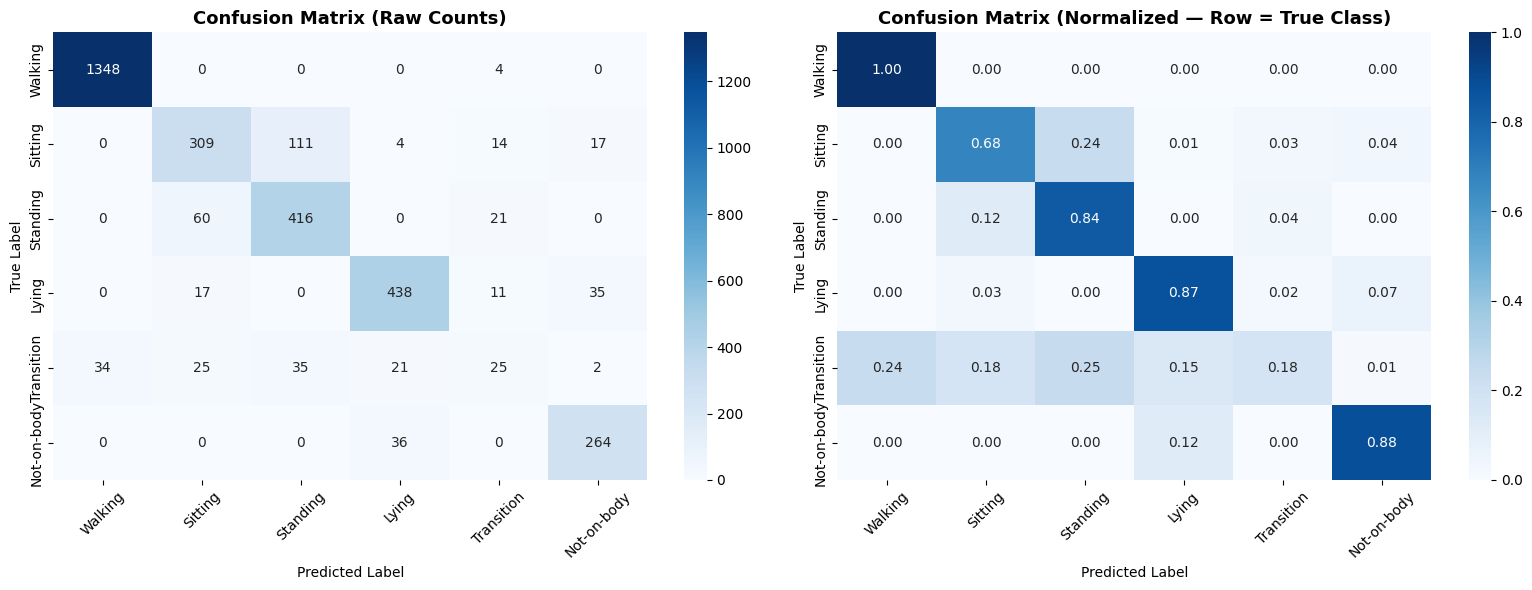

Saved: confusion_matrix.png


In [95]:
# ─── CONFUSION MATRIX ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_final, y_pred)

# Raw counts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# Normalized (row-wise) — shows recall per class as percentage
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap='Blues',
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Normalized — Row = True Class)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

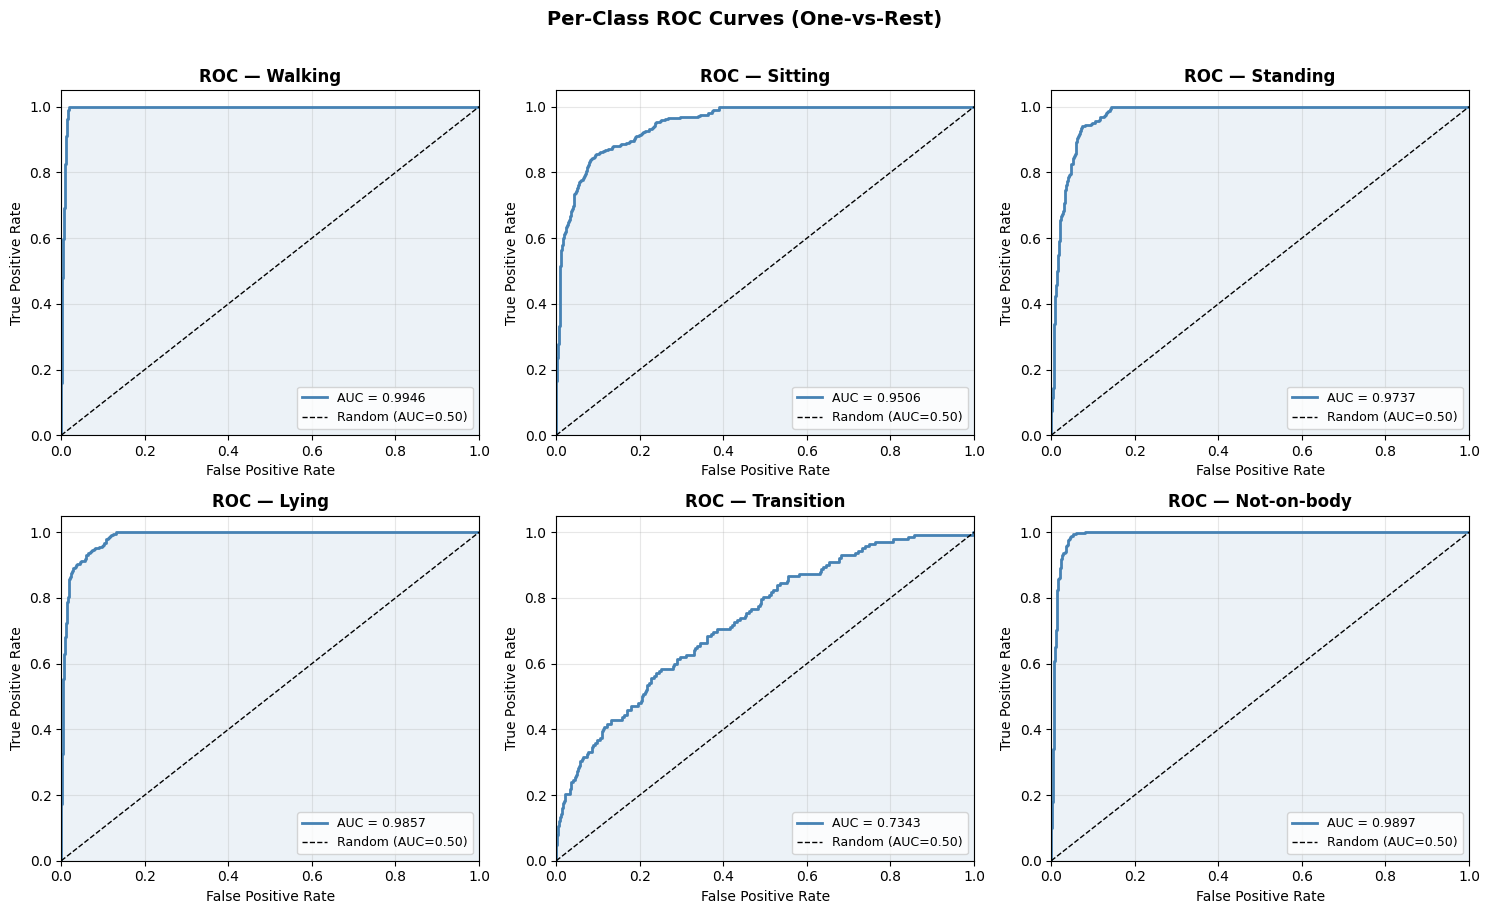

Saved: roc_curves.png

── AUC Scores per Class ──
  ✅ Walking         AUC = 0.9946  ███████████████████
  ✅ Sitting         AUC = 0.9506  ███████████████████
  ✅ Standing        AUC = 0.9737  ███████████████████
  ✅ Lying           AUC = 0.9857  ███████████████████
  ❌ Transition      AUC = 0.7343  ██████████████
  ✅ Not-on-body     AUC = 0.9897  ███████████████████


In [96]:
# ─── ROC CURVES & AUC ─────────────────────────────────────────────────────────
# Binarize true labels for one-vs-rest ROC calculation
y_test_bin = label_binarize(y_test_final, classes=list(range(N_CLASSES)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

auc_scores = {}

for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc      = auc(fpr, tpr)
    auc_scores[class_name] = roc_auc

    axes[i].plot(fpr, tpr, color='steelblue', lw=2,
                 label=f'AUC = {roc_auc:.4f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')
    axes[i].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_title(f'ROC — {class_name}', fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Per-Class ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")

# Print AUC summary
print("\n── AUC Scores per Class ──")
for class_name, score in auc_scores.items():
    bar    = '█' * int(score * 20)
    status = '✅' if score >= 0.95 else ('⚠️ ' if score >= 0.85 else '❌')
    print(f"  {status} {class_name:<15} AUC = {score:.4f}  {bar}")

In [97]:
# ─── MODEL SIZE ───────────────────────────────────────────────────────────────
model.save('har_optimized_model.keras')
model_size_kb = os.path.getsize('har_optimized_model.keras') / 1024

print("╔══════════════════════════════════════════╗")
print("║         MODEL SIZE & COMPLEXITY         ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Total parameters  : {model.count_params():>10,}       ║")
print(f"║  Saved model size  : {model_size_kb:>10.2f} KB      ║")
print("╚══════════════════════════════════════════╝")

# ─── INFERENCE SPEED ──────────────────────────────────────────────────────────
# Single sample latency — what matters on device
single_sample = X_test_norm[0:1]   # shape (1, 128, 8)

# Warm-up run (first inference is always slower due to JIT compilation)
_ = model.predict(single_sample, verbose=0)

# Timed runs
N_RUNS  = 200
latencies = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    _  = model.predict(single_sample, verbose=0)
    t1 = time.perf_counter()
    latencies.append((t1 - t0) * 1000)   # ms

latencies  = np.array(latencies)
print("\n── Inference Latency (single window, 200 runs) ──")
print(f"  Mean    : {latencies.mean():.3f} ms")
print(f"  Median  : {np.median(latencies):.3f} ms")
print(f"  Min     : {latencies.min():.3f} ms")
print(f"  Max     : {latencies.max():.3f} ms")
print(f"  Std Dev : {latencies.std():.3f} ms")

# Real-time feasibility check (window = 2.56s, must predict faster)
window_duration_ms = 2560
print(f"\n  Window duration : {window_duration_ms} ms")
print(f"  Mean latency    : {latencies.mean():.3f} ms")
ratio = latencies.mean() / window_duration_ms
print(f"  Latency ratio   : {ratio:.4f} ({ratio*100:.2f}% of window)")
print(f"  Real-time ready : {'✅ YES' if ratio < 0.1 else '❌ NO'}")

╔══════════════════════════════════════════╗
║         MODEL SIZE & COMPLEXITY         ║
╠══════════════════════════════════════════╣
║  Total parameters  :      1,742       ║
║  Saved model size  :      54.66 KB      ║
╚══════════════════════════════════════════╝

── Inference Latency (single window, 200 runs) ──
  Mean    : 256.922 ms
  Median  : 238.012 ms
  Min     : 204.860 ms
  Max     : 1510.456 ms
  Std Dev : 94.837 ms

  Window duration : 2560 ms
  Mean latency    : 256.922 ms
  Latency ratio   : 0.1004 (10.04% of window)
  Real-time ready : ❌ NO


In [98]:
# ─── TFLITE CONVERSION ────────────────────────────────────────────────────────
print("\n── TFLite Conversion ──")
converter       = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model    = converter.convert()

tflite_path     = 'har_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

tflite_size_kb  = os.path.getsize(tflite_path) / 1024
print(f"  TFLite model size : {tflite_size_kb:.2f} KB")

# Quantized version (INT8) — even smaller for microcontrollers
converter_q                       = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations         = [tf.lite.Optimize.DEFAULT]

# Representative dataset needed for full INT8 quantization
def representative_dataset():
    for i in range(0, min(500, len(X_train_norm)), 1):
        sample = X_train_norm[i:i+1].astype(np.float32)
        yield [sample]

converter_q.representative_dataset  = representative_dataset
converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_q.inference_input_type     = tf.float32
converter_q.inference_output_type    = tf.float32

tflite_quant_model   = converter_q.convert()
tflite_quant_path    = 'har_model_quantized.tflite'
with open(tflite_quant_path, 'wb') as f:
    f.write(tflite_quant_model)

tflite_quant_size_kb = os.path.getsize(tflite_quant_path) / 1024

print(f"  Quantized (INT8) size : {tflite_quant_size_kb:.2f} KB")
print(f"  Size reduction        : {((tflite_size_kb - tflite_quant_size_kb)/tflite_size_kb)*100:.1f}%")

# ─── FINAL SUMMARY TABLE ──────────────────────────────────────────────────────
print("\n")
print("╔══════════════════════════════════════════════════╗")
print("║           FINAL EVALUATION SUMMARY              ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Accuracy (overall)        : {acc:.4f}            ║")
print(f"║  Macro F1 (primary metric) : {f1_macro:.4f}            ║")
print(f"║  Weighted F1 (reference)   : {f1_w:.4f}            ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Parameters                : {model.count_params():>6,}            ║")
print(f"║  Keras model size          : {model_size_kb:>6.2f} KB          ║")
print(f"║  TFLite size               : {tflite_size_kb:>6.2f} KB          ║")
print(f"║  TFLite quantized size     : {tflite_quant_size_kb:>6.2f} KB          ║")
print(f"║  Mean inference latency    : {latencies.mean():>6.3f} ms          ║")
print("╠══════════════════════════════════════════════════╣")
print("║  AUC per class:                                 ║")
for class_name, score in auc_scores.items():
    status = '✅' if score >= 0.95 else ('⚠️ ' if score >= 0.85 else '❌')
    print(f"║    {status} {class_name:<15} : {score:.4f}                ║")
print("╚══════════════════════════════════════════════════╝")



── TFLite Conversion ──
INFO:tensorflow:Assets written to: C:\Users\Fahad\AppData\Local\Temp\tmphytj4z_t\assets


INFO:tensorflow:Assets written to: C:\Users\Fahad\AppData\Local\Temp\tmphytj4z_t\assets


Saved artifact at 'C:\Users\Fahad\AppData\Local\Temp\tmphytj4z_t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 8), dtype=tf.float32, name='keras_tensor_40')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  1947970410576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946615096784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947971203920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947971205072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947982252176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947982254096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947982252944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947982263504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  TFLite model size : 10.81 KB
INFO:tensorflow:Assets written to: C:\Users\Fahad\AppData\Local\Temp\tmpi0kmvee_\assets


INFO:tensorflow:Assets written to: C:\Users\Fahad\AppData\Local\Temp\tmpi0kmvee_\assets


Saved artifact at 'C:\Users\Fahad\AppData\Local\Temp\tmpi0kmvee_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 8), dtype=tf.float32, name='keras_tensor_40')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  1947970410576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1946615096784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947971203920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947971205072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947982252176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947982254096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947982252944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1947982263504: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\Fahad\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  Quantized (INT8) size : 7.83 KB
  Size reduction        : 27.6%


╔══════════════════════════════════════════════════╗
║           FINAL EVALUATION SUMMARY              ║
╠══════════════════════════════════════════════════╣
║  Accuracy (overall)        : 0.8623            ║
║  Macro F1 (primary metric) : 0.7410            ║
║  Weighted F1 (reference)   : 0.8550            ║
╠══════════════════════════════════════════════════╣
║  Parameters                :  1,742            ║
║  Keras model size          :  54.66 KB          ║
║  TFLite size               :  10.81 KB          ║
║  TFLite quantized size     :   7.83 KB          ║
║  Mean inference latency    : 256.922 ms          ║
╠══════════════════════════════════════════════════╣
║  AUC per class:                                 ║
║    ✅ Walking         : 0.9946                ║
║    ✅ Sitting         : 0.9506                ║
║    ✅ Standing        : 0.9737                ║
║    ✅ Lying           : 0.9857                ║
║    ❌ 